## Setup & Imports

In [24]:
import os
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Load DinoV2 Large (Vit-L/14) - Good balance of speed and power
# Note: This will download about 1.1GB of weights on the first run
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14').to(DEVICE)
dinov2.eval()
print(f"DinoV2 loaded on {DEVICE}")

Using cache found in /Users/zuzanna/.cache/torch/hub/facebookresearch_dinov2_main


DinoV2 loaded on mps


In [25]:
# 1. Paths
data_path = "../data/ScanNetPP/30966f4c6e/iphone/"
rgb_path = os.path.join(data_path, "rgb/frame_000000.jpg")
depth_path = os.path.join(data_path, "depth/frame_000000.png")

# 2. Load
rgb = plt.imread(rgb_path)
depth_raw = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)

## The Preprocessing Pipeline

DinoV2 expects 224×224 images. Since objects in ScanNet++ aren't square, the RGB image must be cropped based on the SAM mask (next step) and then resized.

In [26]:
# Function to crop the RGB image to the bounding box of the SAM mask
def get_object_crop(rgb_img, mask):
    """Crops the RGB image to the bounding box of the SAM mask."""
    y, x = np.where(mask)
    y1, y2, x1, x2 = y.min(), y.max(), x.min(), x.max()
    crop = rgb_img[y1:y2, x1:x2]
    return crop

# Standard ImageNet normalization used by DinoV2
transform = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## Object Mask Generation

Generate the best object mask: run SAM (Segment Anything) on a specific pixel (specific location).
This step is essential the DinoV2 feature extraction.

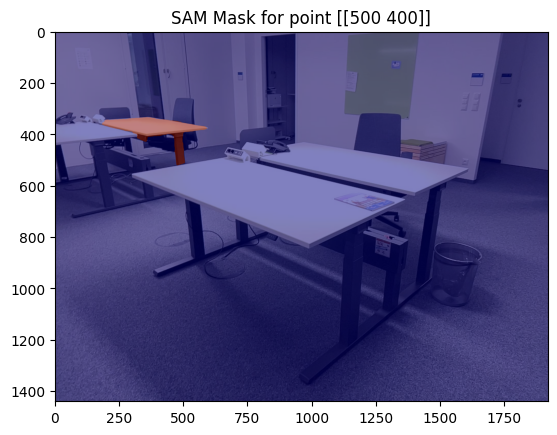

In [27]:
from segment_anything import sam_model_registry, SamPredictor

# 1. Initialize SAM (Assuming you have the weights from earlier)
SAM_CHECKPOINT = "../checkpoints/weights/sam_vit_h_4b8939.pth"
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT).to(DEVICE)
predictor = SamPredictor(sam)

# 2. Tell SAM which image to look at
predictor.set_image((rgb * 255).astype(np.uint8) if rgb.max() <= 1.0 else rgb)

# 3. CHOOSE A POINT: Look at your RGB plot from the previous cell.
# Pick a coordinate (x, y) that lands on a piece of furniture.
# Example: x=500, y=400 (Adjust this based on your image!)
input_point = np.array([[500, 400]]) 
input_label = np.array([1]) # 1 means 'foreground'

# 4. Predict
masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

# 5. Define best_mask
best_mask = masks[np.argmax(scores)]

# Visualize to confirm you caught the right object
plt.imshow(rgb)
plt.imshow(best_mask, alpha=0.5, cmap='jet')
plt.title(f"SAM Mask for point {input_point}")
plt.show()

## Feature Extraction logic

This is where a picture is turned into a "semantic thought" (a vector).

In [28]:
# 1. Get the crop from your ScanNet++ image and SAM mask
obj_crop = get_object_crop(rgb, best_mask) # Using your variables from Part 1
pil_img = Image.fromarray((obj_crop * 255).astype(np.uint8)) # Convert to PIL

# 2. Transform and move to Mac GPU
img_tensor = transform(pil_img).unsqueeze(0).to(DEVICE)

# 3. Inference
with torch.no_grad():
    # Global feature (CLS token)
    features = dinov2(img_tensor) 
    
print(f"Feature Vector Shape: {features.shape}") 
# Should be [1, 1024] for vitl14

Feature Vector Shape: torch.Size([1, 1024])
